# Plot 2D Climatology Maps

Create seasonal climatology and model-reference bias maps for any variable available in the configured NetCDF files. Reusable plotting logic lives in `scripts/climatology_2d_map.py`; edit the setup cell here for each application.


In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "scripts").exists() and (PROJECT_ROOT.parent / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import climatology_2d_map
import pcmdi_climo_reader
importlib.reload(climatology_2d_map)
importlib.reload(pcmdi_climo_reader)

from climatology_2d_map import ClimatologyMapPlotter
from metrics_group_merger import PCMDIRun
from pcmdi_climo_reader import build_experiments_from_pcmdi_runs


In [2]:
# Plot setup. This follows the four test runs used by plot_synthetic_metrics_model_vs_cmip.ipynb.
OUTPUT_DIR = Path("/pscratch/sd/z/zhan391/e3smv4_project/diag_out/2d_maps")
RUN_TYPE = "model_vs_obs"
RUN_PLOTS = False
STRICT_PATHS = False

# Select any variables available in the run mean-climate metric JSONs.
# These four current runs have tas and pr JSONs; add more variables when their climo files are available.
PLOT_VARIABLES = ["tas", "pr"]

# Use "OBS" for variable-specific observational references, or use one model label,
# e.g. "v3.LR.CPL", when you want model-vs-model maps using that model as reference.
REF_NAME = "OBS"
INCLUDE_OBS_REFERENCE = True

VARIABLE_REFERENCE_LABELS = {
    "tas": "ERA5",
    "pr": "GPCP_v2_3",
}
RUN_PLOTS = True

# Roots used to resolve InputClimatologyFileName and References/default/file_path from metric JSONs.
# Add the directory that contains climo files if the summary below reports unresolved paths.
CLIMO_SEARCH_ROOTS = [
    Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    Path("/global/cfs/cdirs/e3sm/diagnostics/pcmdi_data"),
    Path("/pscratch/sd/z/zhan391/e3smv4_project/diag_out"),
]

# Optional per-model roots, useful when climo files are stored outside the raw PCMDI run directory.
# Keys should match output_name values in TEST_RUNS.
CLIMO_SEARCH_ROOTS_BY_MODEL = {
    # "v3.HR.CPL": [Path("/path/to/v3.HR.CPL/mean_climate")],
    # "v4P.CPL": [Path("/path/to/v4P.CPL/mean_climate")],
    # "v4P.AMIP": [Path("/path/to/v4P.AMIP/mean_climate")],
}

TEST_RUNS = [
    PCMDIRun(
        case="20231209.v3.LR.piControl-spinup.chrysalis",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260531",
        output_name="v3.LR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        model_name="v3-HR_test6-1",
        metrics_case_id="v20260601",
        output_name="v3.HR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20260204.ne256.WCYCLXX1850.SOI",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260601",
        output_name="v4P.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        model_name="EAMXX_test2_1",
        metrics_case_id="v20260531",
        output_name="v4P.AMIP",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
]

VARIABLE_UNITS = {
    "tas": "tas (K)",
    "pr": "pr (mm day$^{-1}$)",
}

VARIABLE_SCALE_FACTORS = {
    # Unit-aware precipitation conversion is handled by ClimatologyMapPlotter.
}

VAR_LEVELS = {
    "default": {
        "raw_levels": None,
        "diff_levels": None,
        "cmap_raw": "viridis",
        "cmap_diff": "RdBu_r",
    },
    "tas": {
        "raw_levels": None,
        "diff_levels": [-10, -5, -2, -1, -0.5, 0.5, 1, 2, 5, 10],
        "cmap_raw": "YlOrRd",
        "cmap_diff": "RdBu_r",
    },
    "pr": {
        "raw_levels": None,
        "diff_levels": [-3, -2, -1, -0.5, -0.1, 0.1, 0.5, 1, 2, 3],
        "cmap_raw": "YlGnBu",
        "cmap_diff": "BrBG",
    },
    "psl": {
        "raw_levels": None,
        "diff_levels": [-20, -10, -5, -2, -1, 1, 2, 5, 10, 20],
        "cmap_raw": "YlGnBu",
        "cmap_diff": "BrBG",
    },
}


In [3]:
EXPERIMENTS = build_experiments_from_pcmdi_runs(
    TEST_RUNS,
    PLOT_VARIABLES,
    run_type=RUN_TYPE,
    search_roots=CLIMO_SEARCH_ROOTS,
    search_roots_by_model=CLIMO_SEARCH_ROOTS_BY_MODEL,
    include_reference=INCLUDE_OBS_REFERENCE,
    reference_name=REF_NAME,
    strict=STRICT_PATHS,
)

print("Resolved climatology files:")
for experiment, var_paths in EXPERIMENTS.items():
    print(f"  {experiment}")
    for variable in PLOT_VARIABLES:
        path = var_paths.get(variable)
        print(f"    {variable}: {path if path else 'MISSING'}")

if REF_NAME not in EXPERIMENTS:
    print(f"[WARN] REF_NAME={REF_NAME!r} was not resolved. Set REF_NAME to one of the model labels or add CLIMO_SEARCH_ROOTS.")


Resolved climatology files:
  OBS
    tas: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/mean_climate/climo_ref/obs.historical.ERA5.00.Amon.tas.199501-200412.AC.v20260604.nc
    pr: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/mean_climate/climo_ref/obs.historical.GPCP_v2_3.00.Amon.pr.199501-200412.AC.v20260604.nc
  v3.LR.CPL
    tas: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/mean_climate/climo/e3sm.historical.v3-LR.piControl-spinup.Amon.tas.199501-200412.AC.v20260604.nc
    pr: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/mean_climate/climo/e3sm.historical.v3-LR.piControl-spinup.Amon.pr.199501-200412.AC.v20260604.nc
  v3.HR.CPL
    tas: /global/cfs/cdirs/e3sm/w

/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: Futur

[INFO] Saved /pscratch/sd/z/zhan391/e3smv4_project/diag_out/2d_maps/climatology_bias_grid_tas.png


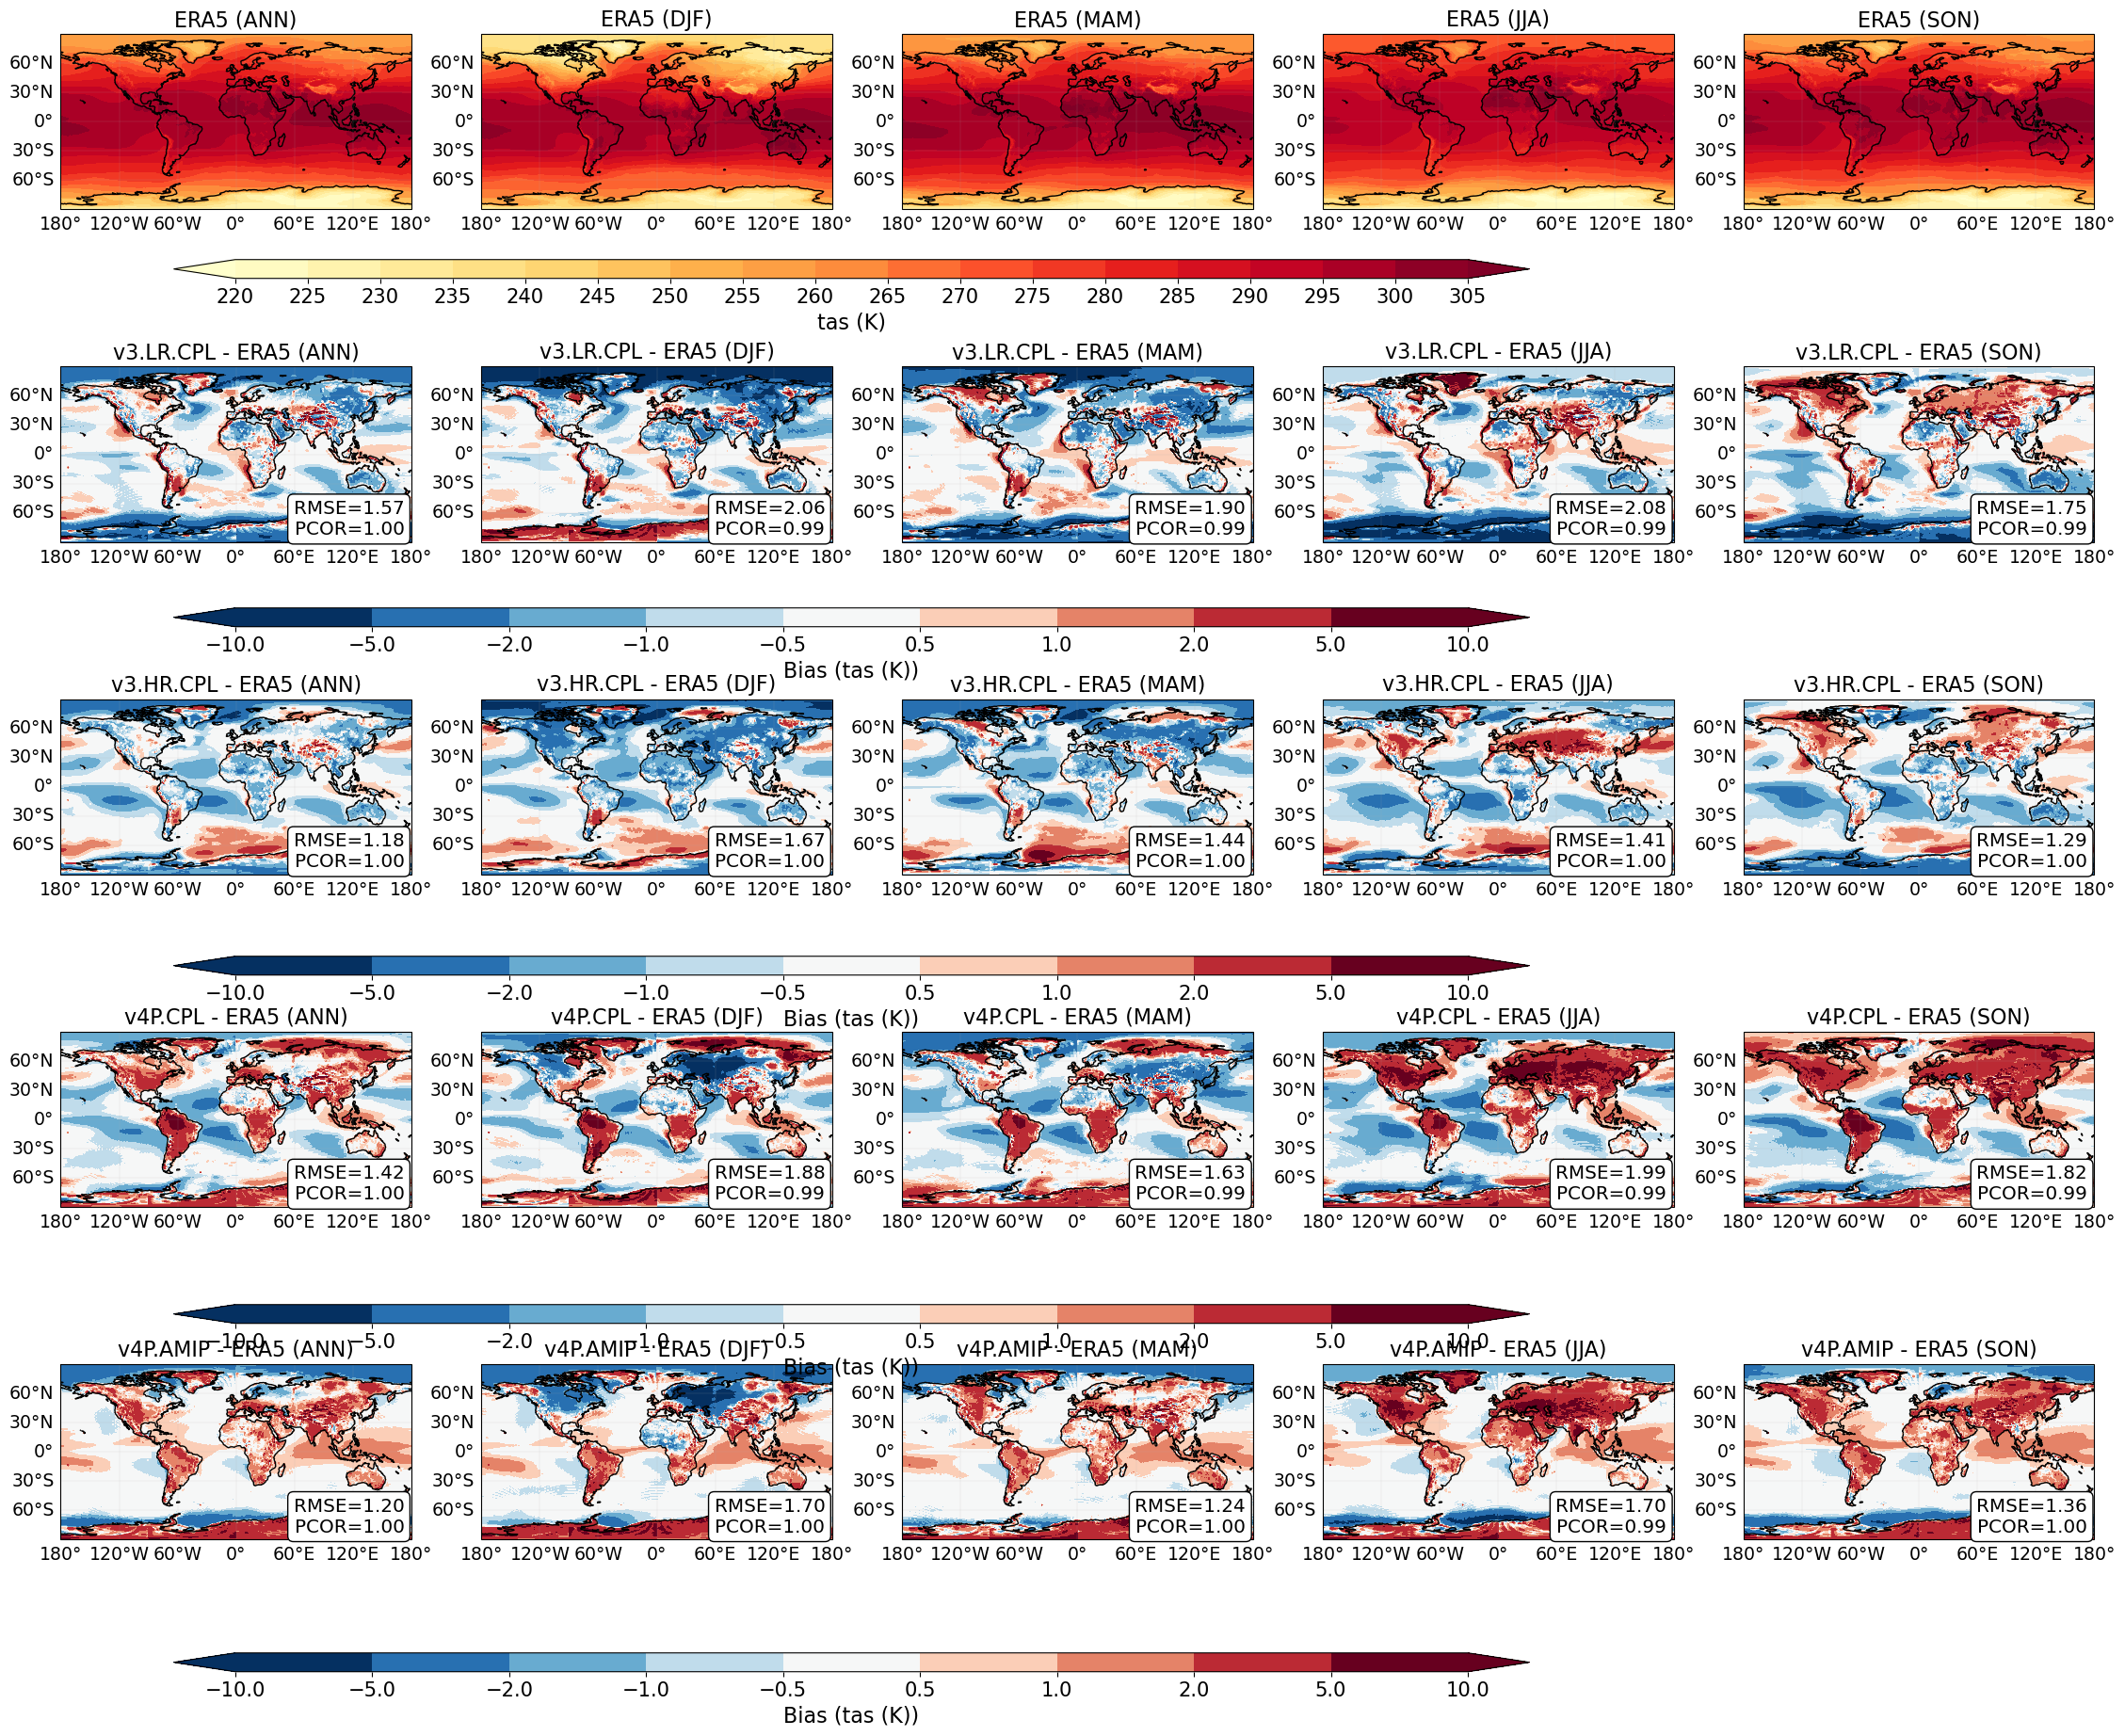

/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: FutureWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  da["time"] = xr.cftime_range(start="2000-01-01", periods=da.sizes["time"], freq="MS")
/pscratch/sd/z/zhan391/e3smv4_project/allhands_meeting/pcmdi_package/scripts/climatology_2d_map.py:144: Futur

[INFO] Saved /pscratch/sd/z/zhan391/e3smv4_project/diag_out/2d_maps/climatology_bias_grid_pr.png


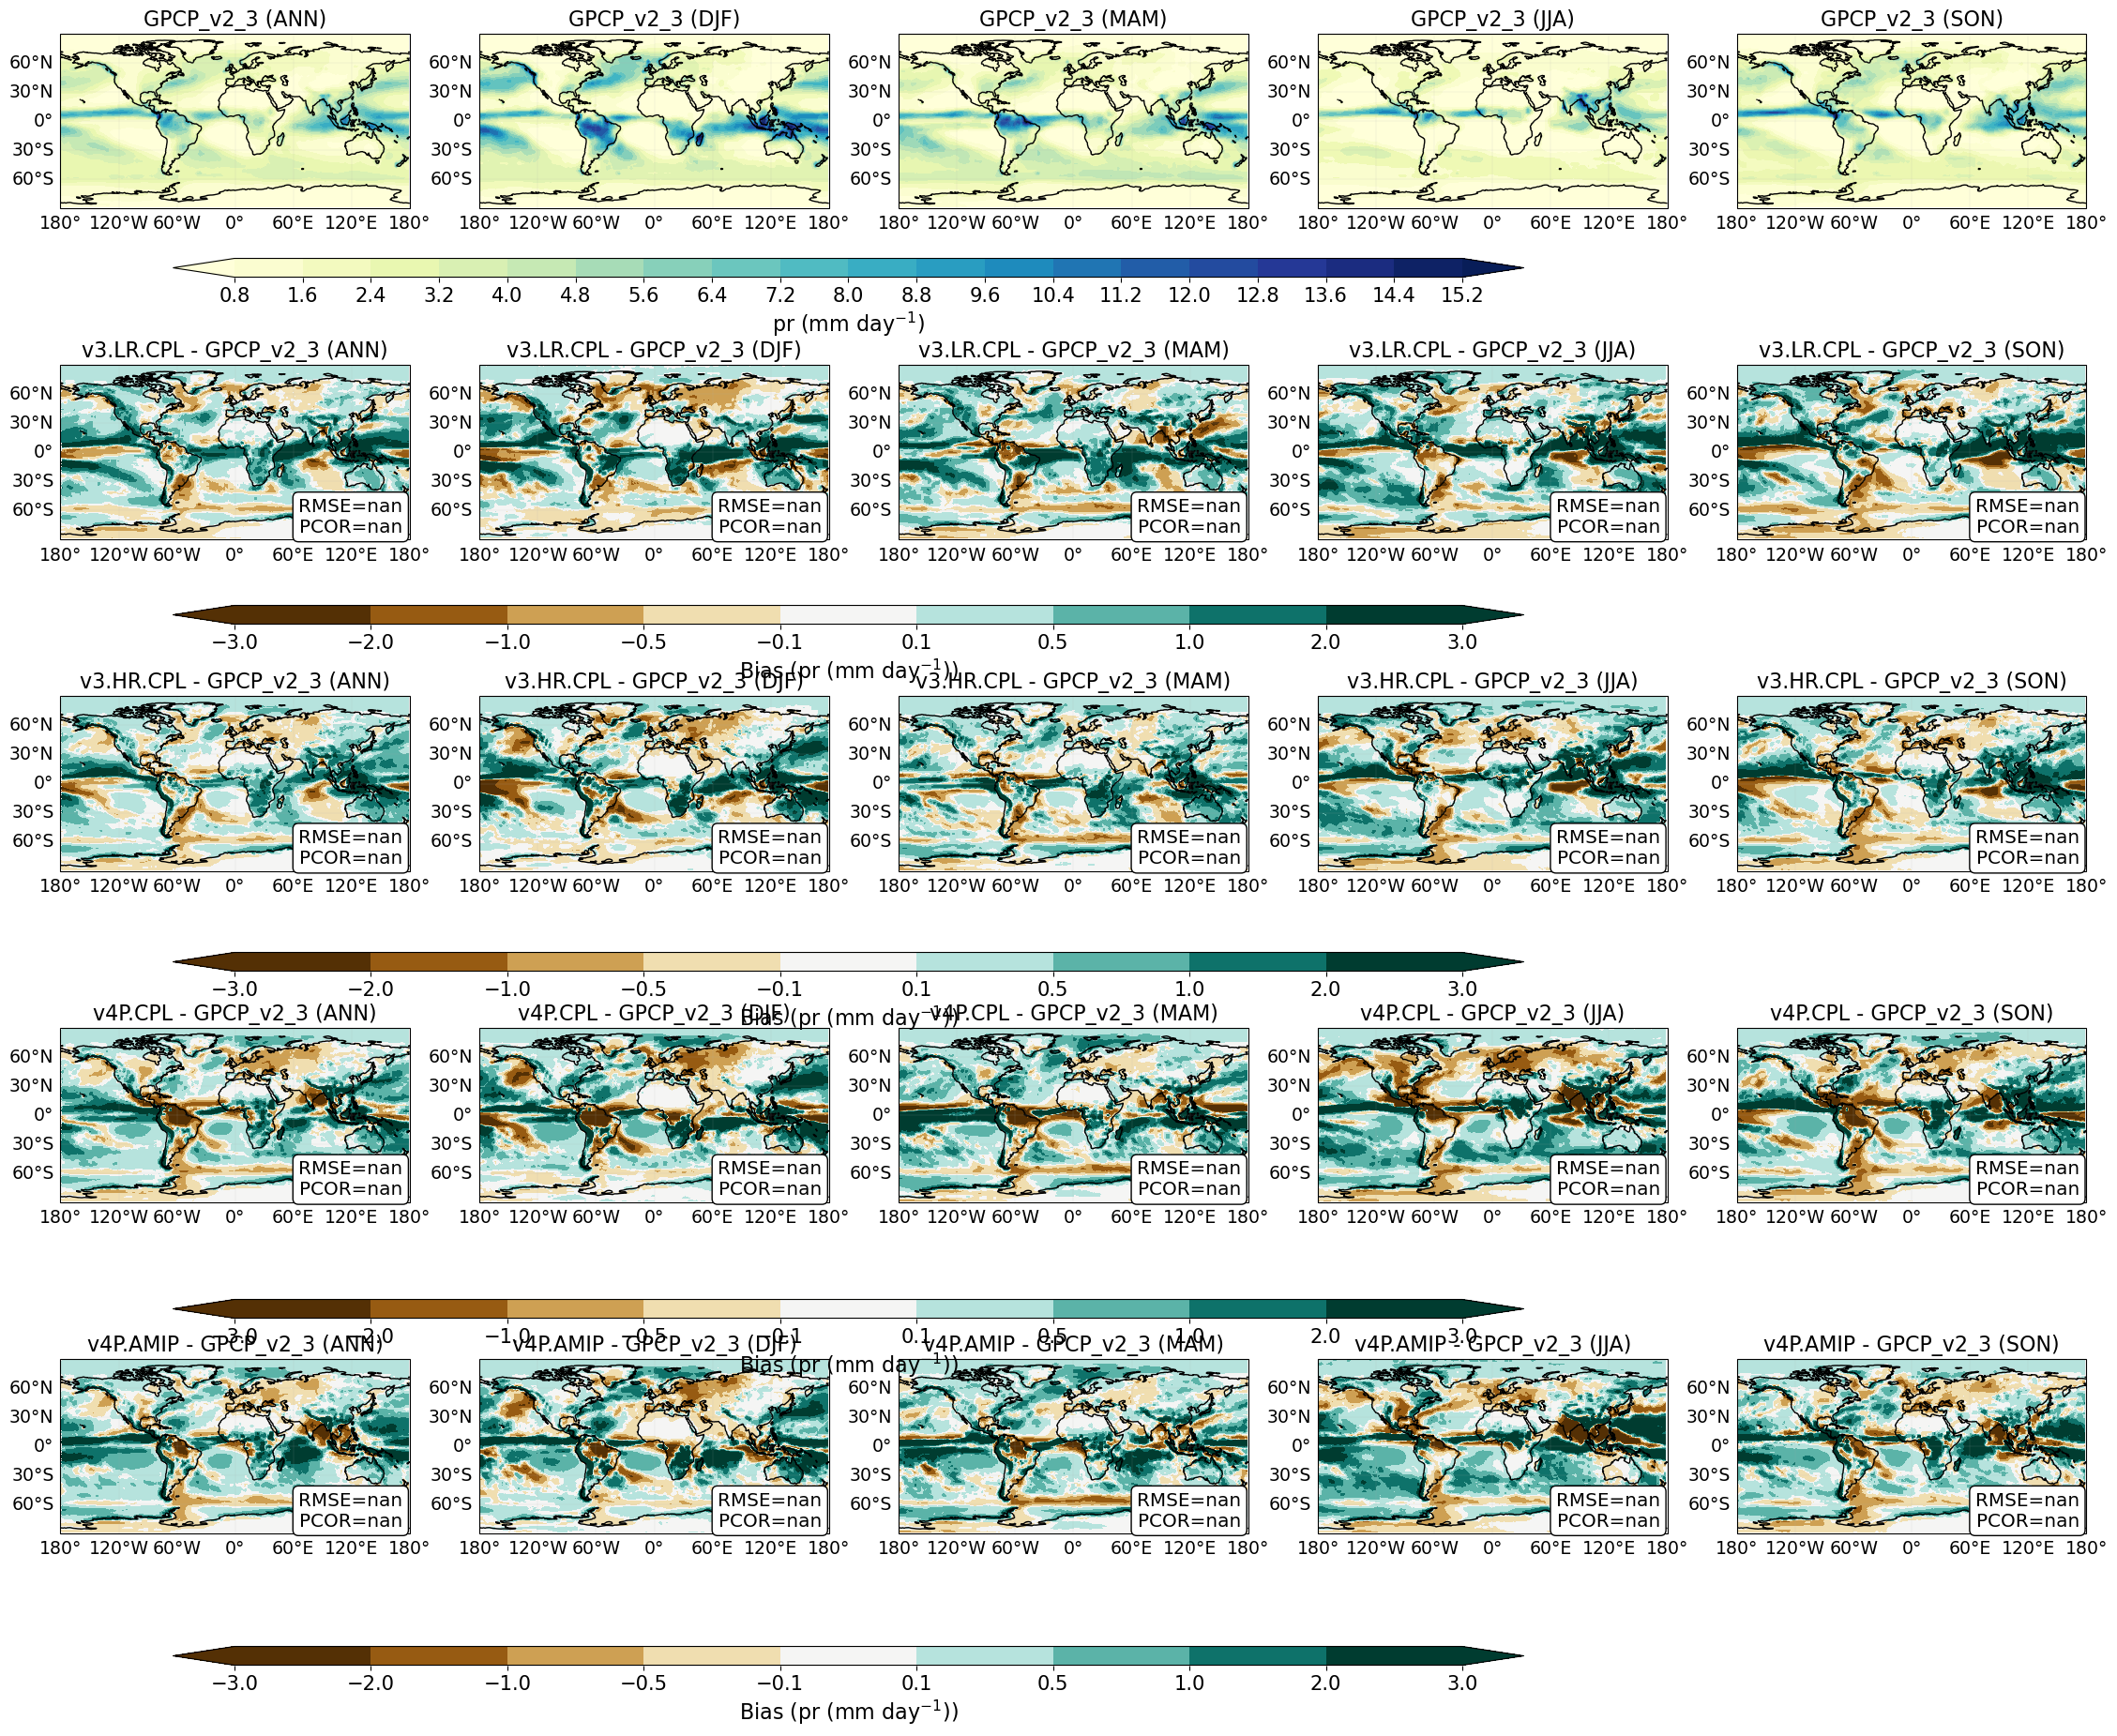

In [4]:
if RUN_PLOTS:
    plotter = ClimatologyMapPlotter(
        EXPERIMENTS,
        save_dir=OUTPUT_DIR,
        ref_name=REF_NAME,
        unit_map=VARIABLE_UNITS,
        scale_map=VARIABLE_SCALE_FACTORS,
    )
    for var_name in PLOT_VARIABLES:
        levels = VAR_LEVELS.get(var_name, VAR_LEVELS["default"])
        plotter.plot_variable(
            var_name=var_name,
            cmap1=levels["cmap_raw"],
            cmap2=levels["cmap_diff"],
            levels1=levels["raw_levels"],
            levels2=levels["diff_levels"],
            font_size=16,
            fig_size=(24, 20),
            ref_label=VARIABLE_REFERENCE_LABELS.get(var_name, REF_NAME),
        )
else:
    print("Set RUN_PLOTS = True after checking the resolved EXPERIMENTS paths above.")
